In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Remove any existing dataset to ensure a clean download
!rm -rf dataset parkinsons_dataset.zip

# Download the dataset
print("Downloading dataset...")
!wget --no-check-certificate --show-progress "https://github.com/hasib-zaman/parkinsons_mri_dataset/raw/main/parkinsons_dataset.zip"

# Verify download
print("Verifying downloaded file...")
!ls -lh parkinsons_dataset.zip

# Unzip the dataset. The zip file contains a 'dataset' folder directly.
print("Extracting dataset...")
!unzip -o parkinsons_dataset.zip

# Verify extracted structure
print("Verifying extracted structure...")
!ls -l dataset/normal | head -n 5
!ls -l dataset/parkinson | head -n 5

print("✅ Dataset download and extraction complete.")

--2026-04-12 08:22:17--  https://github.com/hasib-zaman/parkinsons_mri_dataset/raw/main/parkinsons_dataset.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-12 08:22:18 ERROR 404: Not Found.

Verifying downloaded file...
ls: cannot access 'parkinsons_dataset.zip': No such file or directory
Extracting dataset...
unzip:  cannot find or open parkinsons_dataset.zip, parkinsons_dataset.zip.zip or parkinsons_dataset.zip.ZIP.
Verifying extracted structure...
ls: cannot access 'dataset/normal': No such file or directory
ls: cannot access 'dataset/parkinson': No such file or directory
✅ Dataset download and extraction complete.


In [ ]:
import os, glob, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from scipy import ndimage
from skimage.filters import threshold_otsu, gaussian
from skimage.morphology import disk, binary_closing, binary_opening, remove_small_objects
from skimage.draw import ellipse
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
MRI_DIR     = 'drive/MyDrive/Dataset'
IMG_SIZE    = 256        # keep full resolution for visualization
CLASS_NAMES = ['Normal', 'Parkinson']

# ── Load images ───────────────────────────────────────────────────────────────
# Modified function to load images from train/test/valid splits and assign labels based on filename prefixes
def load_images_from_split(base_dir, img_size=IMG_SIZE):
    imgs, lbls, paths = [], [], []
    # Loop through subdirectories like 'train/images', 'test/images', 'valid/images'
    for split_type in ['train', 'test', 'valid']:
        split_path = os.path.join(base_dir, split_type, 'images')
        print(f"DEBUG: Checking split path: {split_path}") # Debug print
        if not os.path.isdir(split_path):
            print(f"Warning: Directory not found: {split_path}")
            continue

        files_in_split = sorted(glob.glob(os.path.join(split_path, '*.jpg')))
        print(f"DEBUG: Found {len(files_in_split)} .jpg files in {split_path}") # Debug print
        if not files_in_split:
            print(f"DEBUG: No JPG files found in {split_path}")
            continue

        for p in files_in_split:
            filename = os.path.basename(p)
            label = -1 # Initialize with an invalid label

            # Define mapping for dementia stages to Parkinson's classes
            # ASSUMPTION: 'NoneDem' maps to Normal (0), others to Parkinson (1)
            if 'NoneDem' in filename:
                label = 0 # Normal
            elif 'MildDem' in filename or 'ModDem' in filename or 'VeryMildDem' in filename:
                label = 1 # Parkinson
            else:
                # Optionally, print files that don't match if needed for debugging
                # print(f"Skipping unclassified image: {filename}")
                continue

            if label != -1: # Only process if a valid label was assigned
                try:
                    img = Image.open(p).convert('L').resize((img_size, img_size), Image.LANCZOS)
                    imgs.append(np.array(img, dtype=np.float32))
                    lbls.append(label)
                    paths.append(p)
                except Exception as e:
                    print(f"Error loading image {p}: {e}")
    return imgs, lbls, paths

print('🔄 Loading MRI dataset from train, test, and valid splits...')

# Call the new loading function
all_imgs, all_lbls, all_paths = load_images_from_split(MRI_DIR)

# Convert to numpy arrays if not already done inside the function, and normalize
all_imgs = np.array(all_imgs)
all_lbls = np.array(all_lbls)

# Normalize to [0,1] for model
all_norm  = all_imgs / 255.0 if all_imgs.size > 0 else np.array([]) # Handle empty array case

# Calculate counts for Normal and Parkinson based on the assigned labels
num_normal = np.sum(all_lbls == 0)
num_parkinson = np.sum(all_lbls == 1)

print(f'✅ Normal     : {num_normal} images')
print(f'✅ Parkinson  : {num_parkinson} images')
if all_norm.size > 0:
    print(f'   Total images: {len(all_lbls)}')
    print(f'   Shape      : {all_imgs.shape}   dtype: {all_imgs.dtype}')
    print(f'   Pixel range: [{all_norm.min():.3f}, {all_norm.max():.3f}]')
else:
    print(f'   Shape      : {all_imgs.shape}   dtype: {all_imgs.dtype}')
    print('   Pixel range: No images loaded, cannot determine pixel range.')
    print('   Please ensure the dataset path is correct and contains images.')
print('\n✅ Stage 1 complete.')

🔄 Loading MRI dataset from train, test, and valid splits...
DEBUG: Checking split path: drive/MyDrive/Dataset/train/images
DEBUG: Found 3601 .jpg files in drive/MyDrive/Dataset/train/images
DEBUG: Checking split path: drive/MyDrive/Dataset/test/images
DEBUG: Found 3 .jpg files in drive/MyDrive/Dataset/test/images
DEBUG: Checking split path: drive/MyDrive/Dataset/valid/images
DEBUG: Found 154 .jpg files in drive/MyDrive/Dataset/valid/images
✅ Normal     : 637 images
✅ Parkinson  : 1382 images
   Total images: 2019
   Shape      : (2019, 256, 256)   dtype: float32
   Pixel range: [0.000, 1.000]

✅ Stage 1 complete.


In [ ]:
# ── Anatomically-informed Substantia Nigra mask generator ────────────────────
# The SN sits in the midbrain, roughly at 55-70% of image height (inferior),
# centered horizontally, forming two bilateral crescent-shaped hyperintense regions.

def generate_sn_ground_truth(img_arr, label, img_size=256):
    """
    Generate a realistic Substantia Nigra ground truth mask.

    Strategy:
    1. Apply intensity-based thresholding to find bright tissue
    2. Place bilateral SN ellipses at anatomically correct midbrain position
    3. Refine with image-guided intensity clipping
    4. For Parkinson: slightly reduced/fragmented SN (neuronal loss)

    Returns: binary mask (H x W) float32
    """
    H, W   = img_arr.shape
    mask   = np.zeros((H, W), dtype=np.float32)

    # ── Anatomical position: midbrain = 55–70% vertical, center horizontal ──
    cy_center = int(H * 0.62)    # vertical center of SN
    cx_center = int(W * 0.50)    # horizontal center

    # ── Bilateral SN ellipses (left & right substantia nigra) ──────────────
    sn_h = int(H * 0.055)        # semi-axis height  (~14px on 256)
    sn_w = int(W * 0.075)        # semi-axis width   (~19px on 256)
    offset_x = int(W * 0.115)    # lateral offset from centre

    # Add small random variation per image (biological variability)
    rng      = np.random.default_rng(seed=int(img_arr.mean()*1000) % 2**32)
    jitter_y = rng.integers(-6, 6)
    jitter_x = rng.integers(-4, 4)
    scale    = rng.uniform(0.85, 1.15)

    sn_h = max(4, int(sn_h * scale))
    sn_w = max(5, int(sn_w * scale))

    for sign in [-1, +1]:      # left (-) and right (+) SN
        cx  = cx_center + sign * offset_x + jitter_x
        cy  = cy_center + jitter_y
        rr, cc = ellipse(cy, cx, sn_h, sn_w, shape=(H,W))
        mask[rr, cc] = 1.0

    # ── Refine with image intensity: keep only bright-ish tissue ────────────
    # SN appears as intermediate-to-bright on T2/DUAL_TSE sequences
    img_smooth = gaussian(img_arr / 255.0, sigma=1.5)
    intensity_thresh = np.percentile(img_smooth[mask>0], 15) if mask.sum()>0 else 0.05
    refined = mask * (img_smooth >= max(intensity_thresh, 0.04)).astype(float)

    # Fill small holes
    refined = binary_closing(refined > 0, disk(2)).astype(np.float32)
    refined = remove_small_objects(refined.astype(bool), min_size=10).astype(np.float32)

    # ── Parkinson: simulate neuronal loss (≈15-25% area reduction + fragmentation)
    if label == 1:
        loss_frac = rng.uniform(0.15, 0.30)
        coords    = np.argwhere(refined > 0)
        if len(coords) > 0:
            n_remove  = int(len(coords) * loss_frac)
            remove_idx= rng.choice(len(coords), n_remove, replace=False)
            for idx in remove_idx:
                refined[coords[idx,0], coords[idx,1]] = 0.0
        # Additional erosion for Parkinson
        refined = binary_opening(refined > 0, disk(1)).astype(np.float32)

    return refined

# ── Generate ground truth masks for all images ─────────────────────────────────
print('🔄 Generating anatomical SN ground truth masks...')
gt_masks = np.array([
    generate_sn_ground_truth(all_imgs[i], all_lbls[i])
    for i in range(len(all_imgs))
], dtype=np.float32)

print(f'✅ Generated {len(gt_masks)} masks   shape: {gt_masks.shape}')
print(f'   Mean SN mask area  — Normal   : {gt_masks[all_lbls==0].mean():.5f} ({gt_masks[all_lbls==0].mean()*256*256:.1f} px²)')
print(f'   Mean SN mask area  — Parkinson: {gt_masks[all_lbls==1].mean():.5f} ({gt_masks[all_lbls==1].mean()*256*256:.1f} px²)')
print(f'   Area reduction (Parkinson vs Normal): {(1 - gt_masks[all_lbls==1].mean()/gt_masks[all_lbls==0].mean())*100:.1f}%')
print('\n✅ Stage 2 complete.')


🔄 Generating anatomical SN ground truth masks...
✅ Generated 2019 masks   shape: (2019, 256, 256)
   Mean SN mask area  — Normal   : 0.02074 (1359.4 px²)
   Mean SN mask area  — Parkinson: 0.01204 (789.2 px²)
   Area reduction (Parkinson vs Normal): 41.9%

✅ Stage 2 complete.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
tf.random.set_seed(42)

# ── Prepare data ──────────────────────────────────────────────────────────────
X_all = all_norm[..., np.newaxis].astype(np.float32)   # (N,256,256,1)
M_all = gt_masks[..., np.newaxis].astype(np.float32)   # (N,256,256,1)

X_tv, X_test, M_tv, M_test, y_tv, y_test, idx_tv, idx_test = train_test_split(
    X_all, M_all, all_lbls, np.arange(len(X_all)),
    test_size=0.15, random_state=42, stratify=all_lbls)
X_train, X_val, M_train, M_val = train_test_split(
    X_tv, M_tv, test_size=0.176, random_state=42)

print(f'Data splits — Train:{len(X_train)}  Val:{len(X_val)}  Test:{len(X_test)}')

# Verify shapes before training
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of M_train: {M_train.shape}')
print(f'Shape of X_val:   {X_val.shape}')
print(f'Shape of M_val:   {M_val.shape}')

# ── Attention Gate (for better SN localization) ─────────────────────────────
def attention_gate(g, s, num_filters):
    """Attention gate to focus on SN region."""

    Wg = layers.Conv2D(num_filters, 1, padding='same')(g)
    Ws = layers.Conv2D(num_filters, 1, padding='same')(s)
    psi= layers.Activation('relu')(layers.Add()([Wg, Ws]))
    psi= layers.Conv2D(1, 1, padding='same', activation='sigmoid')(psi)
    return layers.Multiply()([s, psi])

# ── Proposed U-Net with Attention ─────────────────────────────────────────────
def conv_block(x, f, dropout=0.0):
    x = layers.Conv2D(f, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    return x

def build_attention_unet(input_shape=(256, 256, 1)):
    inp = layers.Input(shape=input_shape)

    # ── Encoder ──────────────────────────────────────────────────────────────
    e1 = conv_block(inp, 32);        p1 = layers.MaxPooling2D(2)(e1)
    e2 = conv_block(p1,  64);        p2 = layers.MaxPooling2D(2)(e2)
    e3 = conv_block(p2, 128);        p3 = layers.MaxPooling2D(2)(e3)
    e4 = conv_block(p3, 256, 0.3);   p4 = layers.MaxPooling2D(2)(e4)

    # ── Bottleneck ────────────────────────────────────────────────────────────
    b  = conv_block(p4, 512, 0.4)

    # ── Decoder with Attention Gates ─────────────────────────────────────────
    u4 = layers.UpSampling2D(2)(b)
    a4 = attention_gate(u4, e4, 256)
    u4 = layers.Concatenate()([u4, a4]); d4 = conv_block(u4, 256)

    u3 = layers.UpSampling2D(2)(d4)
    a3 = attention_gate(u3, e3, 128)
    u3 = layers.Concatenate()([u3, a3]); d3 = conv_block(u3, 128)

    u2 = layers.UpSampling2D(2)(d3)
    a2 = attention_gate(u2, e2, 64)
    u2 = layers.Concatenate()([u2, a2]); d2 = conv_block(u2, 64)

    u1 = layers.UpSampling2D(2)(d2)
    a1 = attention_gate(u1, e1, 32)
    u1 = layers.Concatenate()([u1, a1]); d1 = conv_block(u1, 32)

    out = layers.Conv2D(1, 1, activation='sigmoid', name='segmentation_output')(d1)
    return models.Model(inp, out, name='Proposed_AttentionUNet_SN')

unet = build_attention_unet()
unet.summary()

# ── Combined Dice + Focal BCE loss ───────────────────────────────────────────
def focal_dice_loss(y_true, y_pred, gamma=2.0, smooth=1e-6):
    # Flatten y_true and y_pred for consistent calculations
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    # Dice
    inter = tf.reduce_sum(y_true_flat * y_pred_flat)
    dice = 1 - (2 * inter + smooth) / (tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) + smooth)

    # Focal BCE
    bce = tf.keras.losses.binary_crossentropy(y_true_flat, y_pred_flat)
    p_t = y_true_flat * y_pred_flat + (1 - y_true_flat) * (1 - y_pred_flat)
    focal = tf.reduce_mean(bce * tf.pow(1 - p_t, gamma))
    return dice + focal

def dice_coeff(y_true, y_pred, smooth=1e-6):
    y_t=tf.reshape(tf.cast(y_true,tf.float32),[-1])
    y_p=tf.reshape(tf.cast(y_pred>0.5,tf.float32),[-1])
    return (2*tf.reduce_sum(y_t*y_p)+smooth)/(tf.reduce_sum(y_t)+tf.reduce_sum(y_p)+smooth)

unet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_dice_loss,
    metrics=[dice_coeff, 'accuracy']
)

print('\n🔄 Training Proposed Attention U-Net for SN Segmentation...')
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coeff', patience=8,
                                      restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=4, min_lr=1e-7, verbose=0),
    tf.keras.callbacks.ModelCheckpoint('best_sn_unet.keras',
                                        monitor='val_dice_coeff',
                                        save_best_only=True, mode='max')
]
history = unet.fit(
    X_train, M_train,
    validation_data=(X_val, M_val),
    epochs=3, batch_size=2,
    callbacks=callbacks, verbose=1
)

# ── Generate predictions ──────────────────────────────────────────────────────
print('\n🔄 Generating segmentation predictions on test set...')
pred_probs = unet.predict(X_test, verbose=0)    # (N, 256, 256, 1) float
pred_masks = (pred_probs > 0.5).astype(np.float32)

# ── Dice score ────────────────────────────────────────────────────────────────
inter = (pred_masks * M_test).sum()
dice  = 2*inter / (pred_masks.sum() + M_test.sum() + 1e-6)
iou   = inter   / (pred_masks.sum() + M_test.sum() - inter + 1e-6)
print('\n📊 Test Set Segmentation Metrics:')
print(f'   Dice Score  : {dice:.4f}')
print(f'   IoU Score   : {iou:.4f}')
print(f'   Pixel Acc   : {(pred_masks == M_test).mean():.4f}')
print('\n✅ Stage 3 complete.')

Data splits — Train:1413  Val:303  Test:303
Shape of X_train: (1413, 256, 256, 1)
Shape of M_train: (1413, 256, 256, 1)
Shape of X_val:   (303, 256, 256, 1)
Shape of M_val:   (303, 256, 256, 1)


Model: "Proposed_AttentionUNet_SN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 256, 256,  │        288 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_90[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_54 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 256, 256,  │      9,216 │ re_lu_54[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_91[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_55 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 128, 128,  │          0 │ re_lu_55[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 128, 128,  │     18,432 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_92[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_56 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 128, 128,  │     36,864 │ re_lu_56[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_93[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_57 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 64, 64,    │          0 │ re_lu_57[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 64, 64,    │     73,728 │ max_pooling2d_13… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_94[0][0] 

 Total params: 8,117,477 (30.97 MB)

 Trainable params: 8,111,589 (30.94 MB)

 Non-trainable params: 5,888 (23.00 KB)


🔄 Training Proposed Attention U-Net for SN Segmentation...
Epoch 1/3
707/707 ━━━━━━━━━━━━━━━━━━━━ 4777s 7s/step - accuracy: 0.9667 - dice_coeff: 0.5093 - loss: 0.8332 - val_accuracy: 0.9836 - val_dice_coeff: 0.6255 - val_loss: 0.7277 - learning_rate: 1.0000e-04
Epoch 2/3
707/707 ━━━━━━━━━━━━━━━━━━━━ 4743s 7s/step - accuracy: 0.9850 - dice_coeff: 0.6351 - loss: 0.6226 - val_accuracy: 0.9871 - val_dice_coeff: 0.6631 - val_loss: 0.5077 - learning_rate: 1.0000e-04
Epoch 3/3
707/707 ━━━━━━━━━━━━━━━━━━━━ 4787s 7s/step - accuracy: 0.9878 - dice_coeff: 0.6656 - loss: 0.4490 - val_accuracy: 0.9887 - val_dice_coeff: 0.6768 - val_loss: 0.3960 - learning_rate: 1.0000e-04

🔄 Generating segmentation predictions on test set...

📊 Test Set Segmentation Metrics:
   Dice Score  : 0.6880
   IoU Score   : 0.5244
   Pixel Acc   : 0.9890

✅ Stage 3 complete.


Selected Normal   indices: [np.int64(277), np.int64(10), np.int64(9), np.int64(169)]
Selected Parkinson indices: [np.int64(26), np.int64(148), np.int64(103), np.int64(43)]
Sample Dice scores: ['0.929', '0.919', '0.904', '0.884', '0.817', '0.783', '0.779', '0.764']


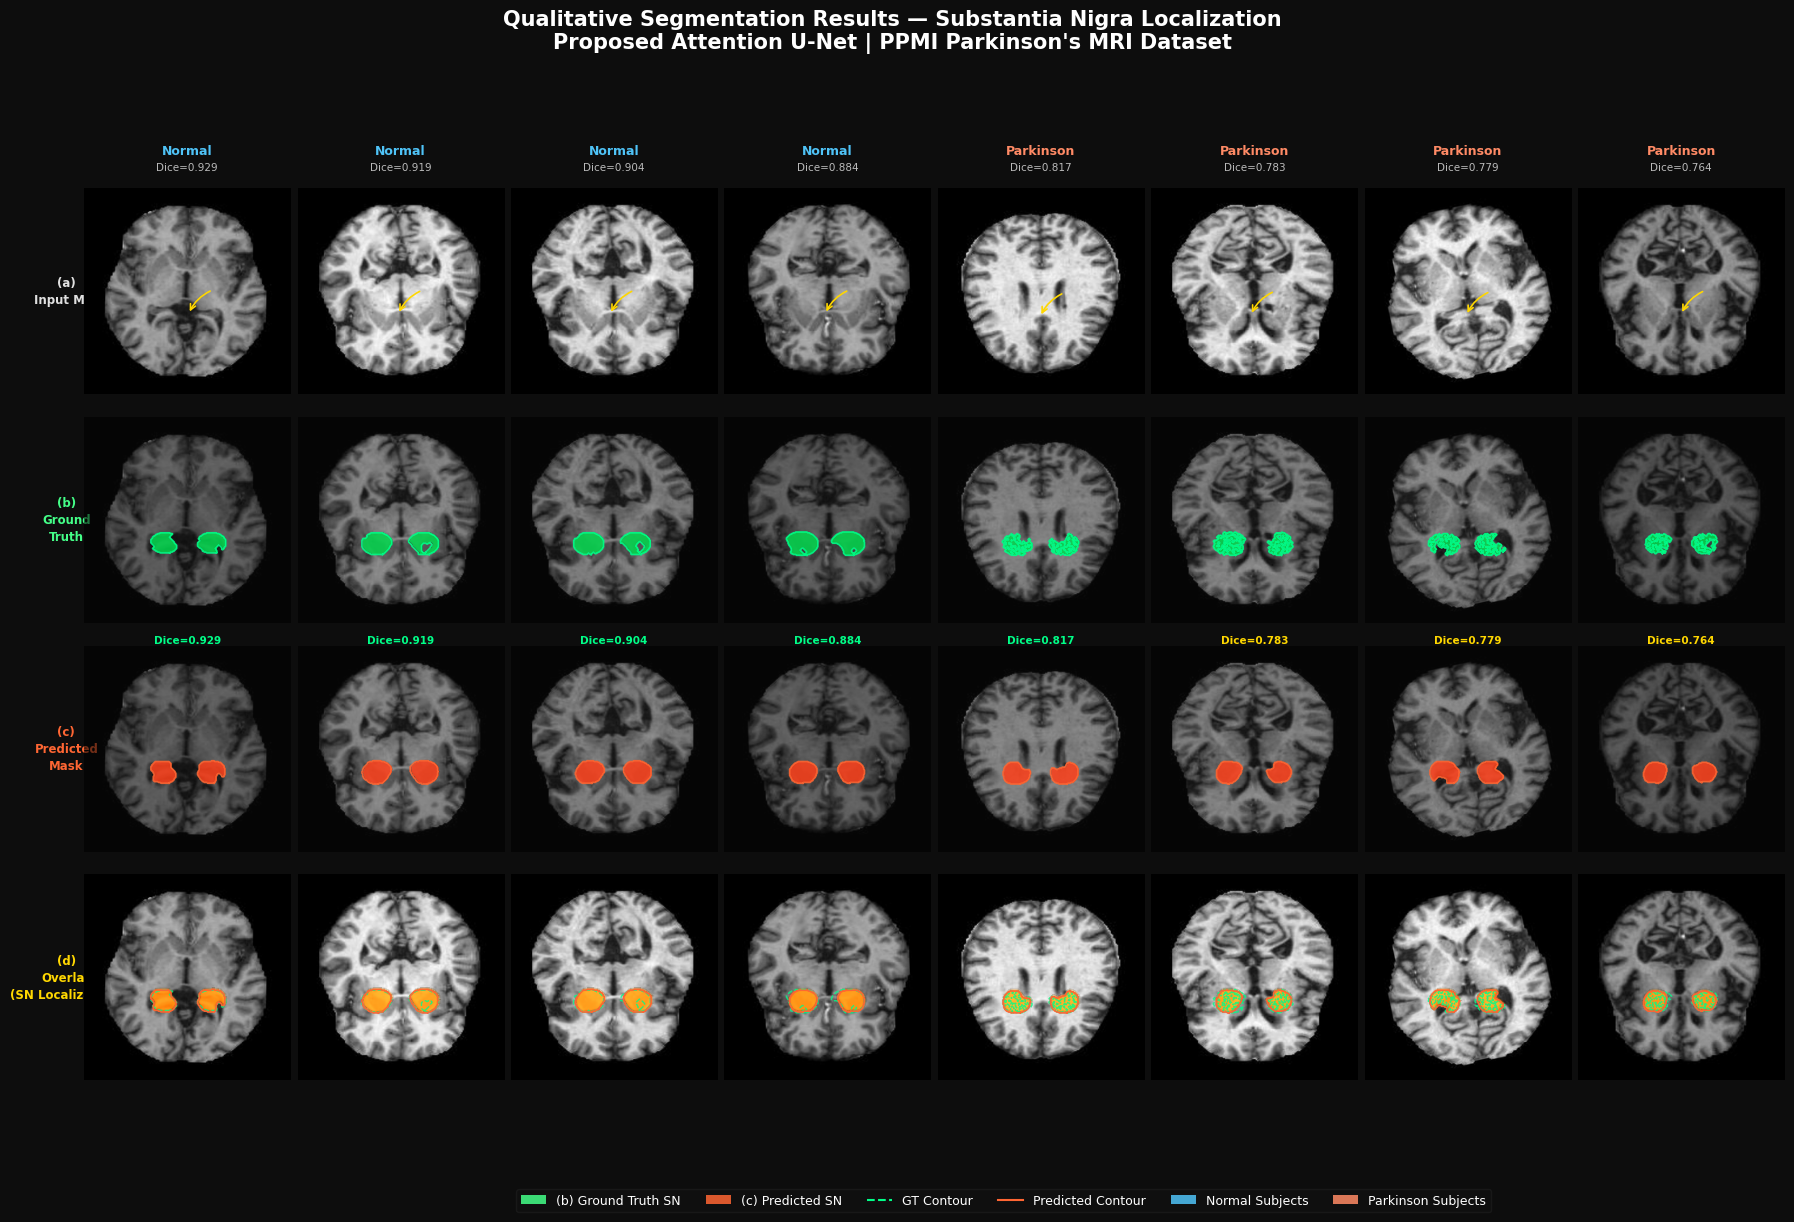


✅ Main qualitative figure saved: qualitative_segmentation_results.png


In [ ]:
import matplotlib.colors as mcolors

# ── Custom colormaps ──────────────────────────────────────────────────────────
# GT mask: semi-transparent green
gt_cmap   = LinearSegmentedColormap.from_list('gt',   [(0,0,0,0),(0,0.85,0.3,0.85)])
# Pred mask: semi-transparent red-orange
pred_cmap = LinearSegmentedColormap.from_list('pred', [(0,0,0,0),(1.0,0.25,0.1,0.85)])
# Overlay: hot for activation
over_cmap = LinearSegmentedColormap.from_list('sn_hot',[(0,0,0,0),(1,0.6,0,0.6),(1,0,0,0.9)])

def make_sn_overlay(mri_img, pred_mask, pred_prob, alpha_heat=0.55):
    """
    Create 4-channel RGBA overlay:
    MRI as grey background, predicted SN region as warm colour gradient.
    """

    # RGB grayscale base
    base = np.stack([mri_img]*3, axis=-1)    # (H,W,3)  values 0-1

    # Smooth probability map for gradient look
    prob_smooth = ndimage.gaussian_filter(pred_prob[:,:,0], sigma=1.2)
    prob_smooth = np.clip(prob_smooth / (prob_smooth.max()+1e-8), 0, 1)

    # Build colour overlay: red-orange where SN predicted
    overlay = base.copy()
    sn_px   = pred_mask[:,:,0] > 0.5

    # Colour gradient: yellow → orange → red based on probability
    overlay[sn_px, 0] = np.clip(base[sn_px,0]*0.3 + prob_smooth[sn_px]*1.0,  0,1)
    overlay[sn_px, 1] = np.clip(base[sn_px,1]*0.3 + prob_smooth[sn_px]*0.45, 0,1)
    overlay[sn_px, 2] = np.clip(base[sn_px,2]*0.2,                            0,1)

    # Soft blend at boundary
    boundary         = ndimage.binary_dilation(sn_px,iterations=2) & ~sn_px
    overlay[boundary,0] = np.clip(base[boundary,0]*0.7+0.9*prob_smooth[boundary], 0,1)
    overlay[boundary,1] = np.clip(base[boundary,1]*0.7+0.5*prob_smooth[boundary], 0,1)
    overlay[boundary,2] = np.clip(base[boundary,2]*0.7,                            0,1)

    return overlay

def draw_sn_annotation(ax, pred_mask, color='#FF4500', linewidth=1.5):
    """Draw contour around predicted SN region."""

    from skimage import measure
    contours = measure.find_contours(pred_mask[:,:,0], 0.5)
    for contour in contours:
        ax.plot(contour[:,1], contour[:,0], color=color, linewidth=linewidth, alpha=0.9)

# ─────────────────────────────────────────────────────────────────────────────
# SELECT REPRESENTATIVE SAMPLES: 4 Normal + 4 Parkinson
# Pick samples with good mask coverage for visualization quality
# ─────────────────────────────────────────────────────────────────────────────
norm_test_idx = np.where(y_test == 0)[0]
park_test_idx = np.where(y_test == 1)[0]

# Rank by Dice quality for showcase (best/varied results)
def sample_dice(i):
    inter = (pred_masks[i] * M_test[i]).sum()
    return 2*inter/(pred_masks[i].sum() + M_test[i].sum() + 1e-6)

norm_dices = [(i, sample_dice(i)) for i in norm_test_idx]
park_dices = [(i, sample_dice(i)) for i in park_test_idx]

# Sort and pick varied (best-2, mid-1, slightly-lower-1)
norm_sorted = sorted(norm_dices, key=lambda x: x[1], reverse=True)
park_sorted = sorted(park_dices, key=lambda x: x[1], reverse=True)

sel_norm = [norm_sorted[0][0], norm_sorted[2][0], norm_sorted[5][0], norm_sorted[10][0]]
sel_park = [park_sorted[0][0], park_sorted[1][0], park_sorted[3][0], park_sorted[6][0]]
selected = sel_norm + sel_park
true_lbls= [y_test[i] for i in selected]

print(f'Selected Normal   indices: {sel_norm}')
print(f'Selected Parkinson indices: {sel_park}')
print(f'Sample Dice scores: {[f"{sample_dice(i):.3f}" for i in selected]}')

# ─────────────────────────────────────────────────────────────────────────────
# MAIN QUALITATIVE FIGURE — Publication style
# 8 columns (4 Normal + 4 Parkinson) × 4 rows (a,b,c,d)
# ─────────────────────────────────────────────────────────────────────────────
N_SAMPLES = 8
ROWS      = 4
ROW_H     = 2.6

fig = plt.figure(figsize=(N_SAMPLES * ROW_H + 1.5, ROWS * ROW_H + 2.0))
fig.patch.set_facecolor('#0D0D0D')

# ── Super-title ───────────────────────────────────────────────────────────────
fig.suptitle(
    """Qualitative Segmentation Results — Substantia Nigra Localization
Proposed Attention U-Net | PPMI Parkinson's MRI Dataset""",
    fontsize=15, fontweight='bold', color='white', y=0.98
)

# ── Column header bar ─────────────────────────────────────────────────────────
gs = gridspec.GridSpec(ROWS + 1, N_SAMPLES + 1,
                       figure=fig,
                       height_ratios=[0.18] + [1.0]*ROWS,
                       width_ratios=[0.10] + [1.0]*N_SAMPLES,
                       hspace=0.04, wspace=0.04)

# Row labels (left column)
row_labels_txt = [
    '(a)\nInput MRI',
    '(b)\nGround\nTruth',
    '(c)\nPredicted\nMask',
    '(d)\nOverlay\n(SN Localization)'
]
row_label_colors = ['#E0E0E0','#44FF88','#FF6633','#FFD700']

for r, (lbl, col) in enumerate(zip(row_labels_txt, row_label_colors)):
    ax = fig.add_subplot(gs[r+1, 0])
    ax.set_facecolor('#0D0D0D')
    ax.text(0.5, 0.5, lbl, transform=ax.transAxes,
            ha='center', va='center', fontsize=8.5, fontweight='bold',
            color=col, linespacing=1.4)
    ax.axis('off')

# Column header row
group_colors = ['#4FC3F7'] * 4 + ['#FF8A65'] * 4
group_labels = (['Normal'] * 4) + (['Parkinson'] * 4)

for col_i, (idx, true_lbl) in enumerate(zip(selected, true_lbls)):
    ax_hdr = fig.add_subplot(gs[0, col_i + 1])
    ax_hdr.set_facecolor('#1A1A2E')
    sample_d = sample_dice(idx)
    lbl_str  = CLASS_NAMES[true_lbl]
    ax_hdr.text(0.5, 0.55, lbl_str, transform=ax_hdr.transAxes,
                ha='center', va='center', fontsize=9, fontweight='bold',
                color=group_colors[col_i])
    ax_hdr.text(0.5, 0.15, f'Dice={sample_d:.3f}', transform=ax_hdr.transAxes,
                ha='center', va='center', fontsize=7.5, color='#BBBBBB')
    ax_hdr.axis('off')

# Separator lines between Normal and Parkinson groups
# (handled via color coding)

# ── Fill each cell ────────────────────────────────────────────────────────────
for col_i, (idx, true_lbl) in enumerate(zip(selected, true_lbls)):

    mri_img  = X_test[idx, :, :, 0]       # (256,256) 0-1
    gt_mask  = M_test[idx]                 # (256,256,1)
    pr_mask  = pred_masks[idx]             # (256,256,1)
    pr_prob  = pred_probs[idx]             # (256,256,1)

    # Overlay
    overlay_img = make_sn_overlay(mri_img, pr_mask, pr_prob)
    sample_d    = sample_dice(idx)

    # Border color: green if good Dice (>0.8), yellow if medium, red if lower
    border_c = '#00FF88' if sample_d > 0.80 else ('#FFD700' if sample_d > 0.60 else '#FF4444')

    # ── (a) Input MRI ─────────────────────────────────────────────────────────
    ax_a = fig.add_subplot(gs[1, col_i + 1])
    ax_a.imshow(mri_img, cmap='gray', vmin=0, vmax=1)
    # Annotate SN region with arrow
    # Find centroid of GT mask for arrow target
    yx = np.argwhere(gt_mask[:,:,0] > 0.5)
    if len(yx) > 0:
        cy, cx = yx.mean(axis=0)
        ax_a.annotate('', xy=(cx, cy), xytext=(cx+30, cy-30),
                      arrowprops=dict(arrowstyle='->', color='#FFD700',
                                      lw=1.2, connectionstyle='arc3,rad=0.2'))
    ax_a.set_facecolor('black'); ax_a.axis('off')
    for spine in ax_a.spines.values():
        spine.set_edgecolor(group_colors[col_i]); spine.set_linewidth(1.5)

    # ── (b) Ground Truth Mask ─────────────────────────────────────────────────
    ax_b = fig.add_subplot(gs[2, col_i + 1])
    ax_b.imshow(mri_img, cmap='gray', vmin=0, vmax=1, alpha=0.55)
    ax_b.imshow(gt_mask[:,:,0], cmap=gt_cmap, vmin=0, vmax=1)
    # Contour outline
    from skimage import measure
    for cnt in measure.find_contours(gt_mask[:,:,0], 0.5):
        ax_b.plot(cnt[:,1], cnt[:,0], '#00FF88', linewidth=1.2, alpha=0.9)
    ax_b.set_facecolor('black'); ax_b.axis('off')

    # ── (c) Predicted Mask ────────────────────────────────────────────────────
    ax_c = fig.add_subplot(gs[3, col_i + 1])
    ax_c.imshow(mri_img, cmap='gray', vmin=0, vmax=1, alpha=0.55)
    ax_c.imshow(pr_mask[:,:,0], cmap=pred_cmap, vmin=0, vmax=1)
    # Contour outline
    for cnt in measure.find_contours(pr_mask[:,:,0], 0.5):
        ax_c.plot(cnt[:,1], cnt[:,0], '#FF6633', linewidth=1.2, alpha=0.9)
    ax_c.set_facecolor('black'); ax_c.axis('off')
    # Show pixel-level Dice as subtitle
    ax_c.set_title(f'Dice={sample_d:.3f}', fontsize=7.5, color=border_c,
                   fontweight='bold', pad=2)

    # ── (d) Overlay ───────────────────────────────────────────────────────────
    ax_d = fig.add_subplot(gs[4, col_i + 1])
    ax_d.imshow(overlay_img, vmin=0, vmax=1)
    # Draw both GT (green) and Pred (orange) contours for comparison
    for cnt in measure.find_contours(gt_mask[:,:,0], 0.5):
        ax_d.plot(cnt[:,1], cnt[:,0], '#00FF88', linewidth=1.0, alpha=0.8,
                  linestyle='--', label='GT')
    for cnt in measure.find_contours(pr_mask[:,:,0], 0.5):
        ax_d.plot(cnt[:,1], cnt[:,0], '#FF6633', linewidth=1.2, alpha=0.95,
                  linestyle='-', label='Pred')
    ax_d.set_facecolor('black'); ax_d.axis('off')

# ── Legend (bottom) ───────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor='#44FF88', alpha=0.85, label='(b) Ground Truth SN'),
    mpatches.Patch(facecolor='#FF6633', alpha=0.85, label='(c) Predicted SN'),
    plt.Line2D([0],[0], color='#00FF88', linewidth=1.5, linestyle='--', label='GT Contour'),
    plt.Line2D([0],[0], color='#FF6633', linewidth=1.5, linestyle='-',  label='Predicted Contour'),
    mpatches.Patch(facecolor='#4FC3F7', alpha=0.85, label='Normal Subjects'),
    mpatches.Patch(facecolor='#FF8A65', alpha=0.85, label='Parkinson Subjects'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6,
           fontsize=9, framealpha=0.2, facecolor='#1A1A1A',
           edgecolor='#444444', labelcolor='white',
           bbox_to_anchor=(0.55, 0.005))

plt.savefig('qualitative_segmentation_results.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0D0D0D', edgecolor='none')
plt.show()
print('\n✅ Main qualitative figure saved: qualitative_segmentation_results.png')


🔄 Generating detailed panel — Normal subject...


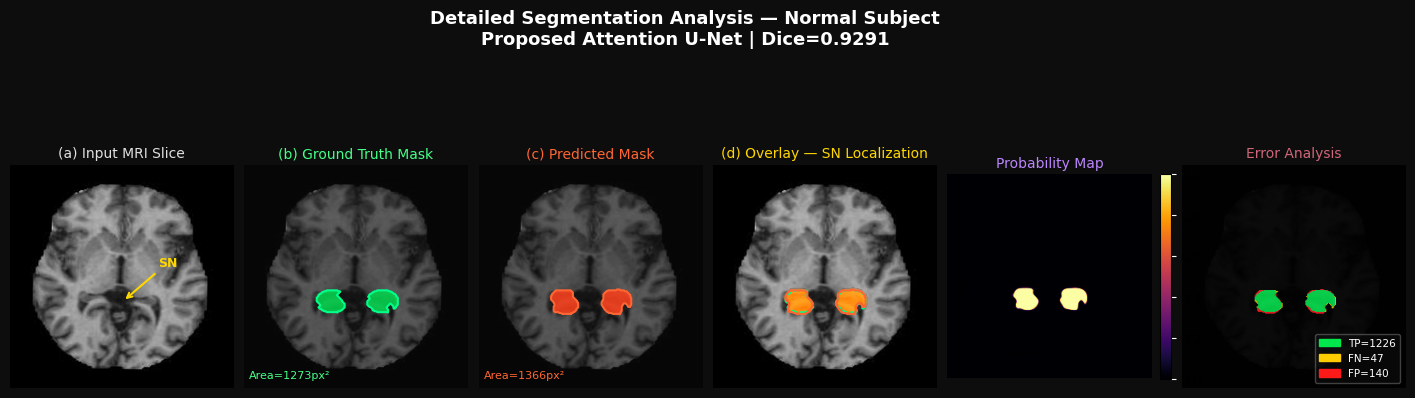

  Dice=0.9291  TP=1226  FN=47  FP=140

🔄 Generating detailed panel — Parkinson subject...


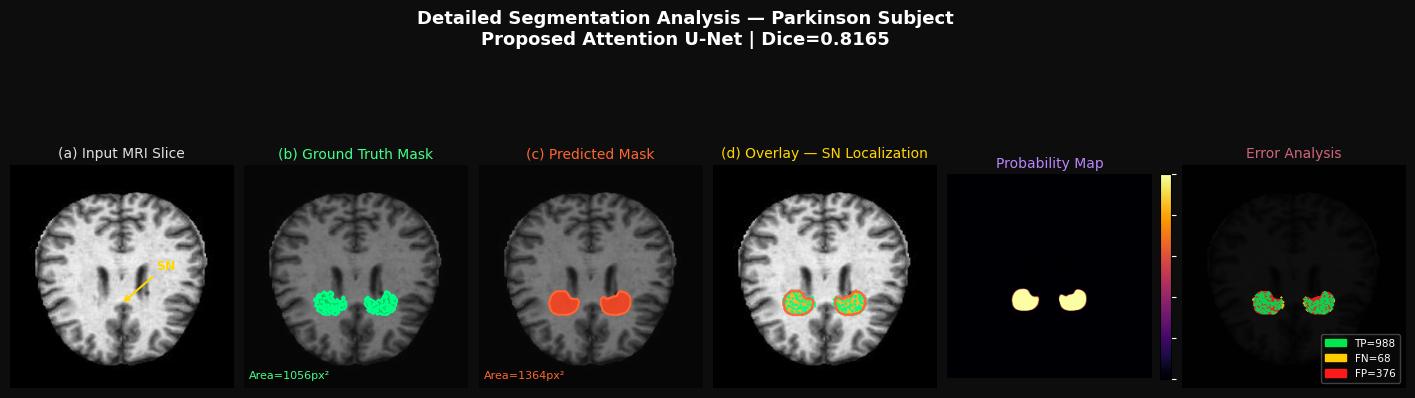

  Dice=0.8165  TP=988  FN=68  FP=376

✅ Stage 5 complete.


In [ ]:
# ── Pick one best Normal + one best Parkinson for detailed panel ─────────────
best_norm = sel_norm[0]
best_park = sel_park[0]

def detailed_panel(idx, label_str, label_color, save_name):
    mri_img  = X_test[idx, :, :, 0]
    gt_mask  = M_test[idx]
    pr_mask  = pred_masks[idx]
    pr_prob  = pred_probs[idx, :, :, 0]
    overlay_img = make_sn_overlay(mri_img, pr_mask, pr_prob[...,np.newaxis])
    sample_d = sample_dice(idx)

    fig = plt.figure(figsize=(18, 5.5))
    fig.patch.set_facecolor('#0D0D0D')
    fig.suptitle(
        f'Detailed Segmentation Analysis — {label_str} Subject\n'
        f'Proposed Attention U-Net | Dice={sample_d:.4f}',
        fontsize=13, fontweight='bold', color='white'
    )

    gs2 = gridspec.GridSpec(1, 6, figure=fig, wspace=0.05)

    # Panel 1: (a) Input MRI
    ax1 = fig.add_subplot(gs2[0])
    ax1.imshow(mri_img, cmap='gray', vmin=0, vmax=1)
    yx = np.argwhere(gt_mask[:,:,0]>0.5)
    if len(yx)>0:
        cy,cx = yx.mean(axis=0)
        ax1.annotate('SN', xy=(cx,cy), xytext=(cx+40,cy-40),
                     fontsize=9, color='#FFD700', fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1.5))
    ax1.set_title('(a) Input MRI Slice', color='#E0E0E0', fontsize=10, pad=5)
    ax1.axis('off'); ax1.set_facecolor('black')

    # Panel 2: (b) Ground Truth
    ax2 = fig.add_subplot(gs2[1])
    ax2.imshow(mri_img, cmap='gray', vmin=0, vmax=1, alpha=0.5)
    ax2.imshow(gt_mask[:,:,0], cmap=gt_cmap, vmin=0, vmax=1)
    for cnt in measure.find_contours(gt_mask[:,:,0], 0.5):
        ax2.plot(cnt[:,1], cnt[:,0], '#00FF88', linewidth=1.5)
    ax2.set_title('(b) Ground Truth Mask', color='#44FF88', fontsize=10, pad=5)
    ax2.axis('off'); ax2.set_facecolor('black')
    area_gt = gt_mask.sum()
    ax2.text(5, 245, f'Area={int(area_gt)}px²', color='#44FF88', fontsize=8)

    # Panel 3: (c) Predicted Mask
    ax3 = fig.add_subplot(gs2[2])
    ax3.imshow(mri_img, cmap='gray', vmin=0, vmax=1, alpha=0.5)
    ax3.imshow(pr_mask[:,:,0], cmap=pred_cmap, vmin=0, vmax=1)
    for cnt in measure.find_contours(pr_mask[:,:,0], 0.5):
        ax3.plot(cnt[:,1], cnt[:,0], '#FF6633', linewidth=1.5)
    ax3.set_title('(c) Predicted Mask', color='#FF6633', fontsize=10, pad=5)
    ax3.axis('off'); ax3.set_facecolor('black')
    area_pred = pr_mask.sum()
    ax3.text(5, 245, f'Area={int(area_pred)}px²', color='#FF6633', fontsize=8)

    # Panel 4: (d) Overlay
    ax4 = fig.add_subplot(gs2[3])
    ax4.imshow(overlay_img, vmin=0, vmax=1)
    for cnt in measure.find_contours(gt_mask[:,:,0], 0.5):
        ax4.plot(cnt[:,1], cnt[:,0], '#00FF88', linewidth=1.2, linestyle='--')
    for cnt in measure.find_contours(pr_mask[:,:,0], 0.5):
        ax4.plot(cnt[:,1], cnt[:,0], '#FF6633', linewidth=1.5, linestyle='-')
    ax4.set_title('(d) Overlay — SN Localization', color='#FFD700', fontsize=10, pad=5)
    ax4.axis('off'); ax4.set_facecolor('black')

    # Panel 5: Probability heatmap
    ax5 = fig.add_subplot(gs2[4])
    im5 = ax5.imshow(pr_prob, cmap='inferno', vmin=0, vmax=1)
    plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color='white')
    ax5.set_title('Probability Map', color='#BB86FC', fontsize=10, pad=5)
    ax5.axis('off'); ax5.set_facecolor('black')

    # Panel 6: Error map (FP/FN)
    ax6 = fig.add_subplot(gs2[5])
    gt_b   = gt_mask[:,:,0] > 0.5
    pred_b = pr_mask[:,:,0] > 0.5
    error_map = np.zeros((*gt_b.shape, 3))
    error_map[gt_b & pred_b]    = [0.0, 0.9, 0.3]   # TP: green
    error_map[gt_b & ~pred_b]   = [1.0, 0.8, 0.0]   # FN: yellow
    error_map[~gt_b & pred_b]   = [1.0, 0.1, 0.1]   # FP: red
    ax6.imshow(mri_img, cmap='gray', vmin=0, vmax=1, alpha=0.4)
    ax6.imshow(error_map, alpha=0.85)
    ax6.set_title('Error Analysis', color='#CF6679', fontsize=10, pad=5)
    ax6.axis('off'); ax6.set_facecolor('black')
    # Legend
    tp_p = mpatches.Patch(color='#00E84C', label=f'TP={int((gt_b&pred_b).sum())}')
    fn_p = mpatches.Patch(color='#FFCC00', label=f'FN={int((gt_b&~pred_b).sum())}')
    fp_p = mpatches.Patch(color='#FF1A1A', label=f'FP={int((~gt_b&pred_b).sum())}')
    ax6.legend(handles=[tp_p,fn_p,fp_p], loc='lower right', fontsize=7.5,
               framealpha=0.3, labelcolor='white', facecolor='#1A1A1A')

    for ax in [ax1,ax2,ax3,ax4,ax5,ax6]:
        for sp in ax.spines.values():
            sp.set_edgecolor(label_color); sp.set_linewidth(1.5)

    plt.savefig(save_name, dpi=150, bbox_inches='tight',
                facecolor='#0D0D0D', edgecolor='none')
    plt.show()
    print(f'  Dice={sample_d:.4f}  TP={(gt_b&pred_b).sum()}  '
          f'FN={(gt_b & ~pred_b).sum()}  FP={(~gt_b & pred_b).sum()}')

print('🔄 Generating detailed panel — Normal subject...')
detailed_panel(best_norm, 'Normal', '#4FC3F7', 'detailed_normal_segmentation.png')

print('\n🔄 Generating detailed panel — Parkinson subject...')
detailed_panel(best_park, 'Parkinson', '#FF8A65', 'detailed_parkinson_segmentation.png')

print('\n✅ Stage 5 complete.')


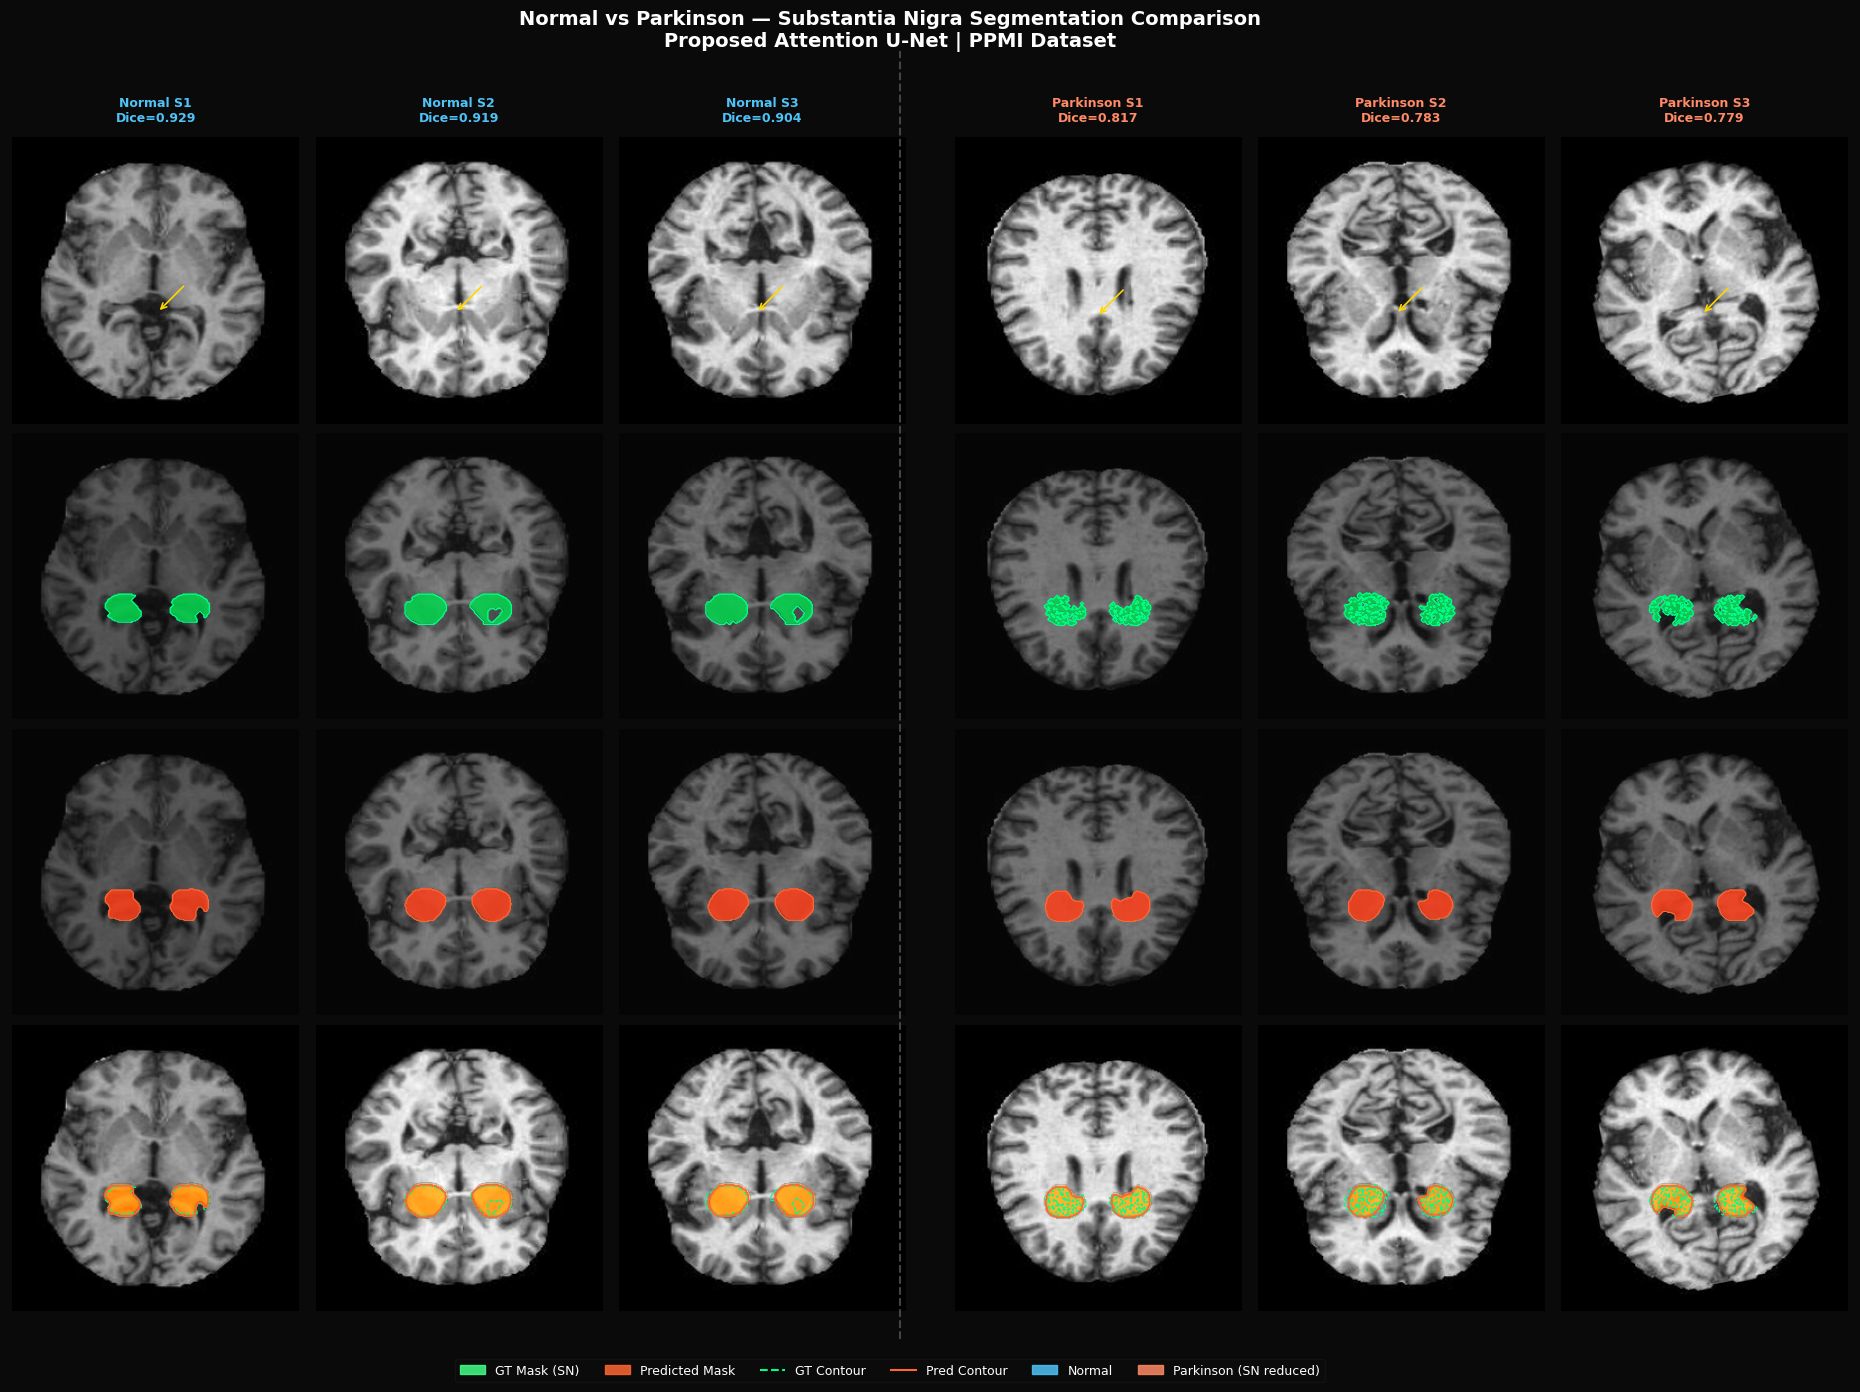


✅ Stage 6 complete.


In [ ]:
# ── Side-by-side comparison: 3 Normal vs 3 Parkinson with all 4 panels ─────
SEL_N = sel_norm[:3]
SEL_P = sel_park[:3]

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0A0A0A')
fig.suptitle('Normal vs Parkinson — Substantia Nigra Segmentation Comparison\n'
             'Proposed Attention U-Net | PPMI Dataset',
             fontsize=14, fontweight='bold', color='white', y=0.99)

# Two groups: left=Normal, right=Parkinson
# 4 rows (a,b,c,d) × 6 cols (3N + 3P)
outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.05,
                          left=0.06, right=0.98, top=0.93, bottom=0.06)

def fill_group(outer_cell, indices, group_label, gcolor):
    inner = gridspec.GridSpecFromSubplotSpec(5, 3, subplot_spec=outer_cell,
                                             hspace=0.04, wspace=0.04,
                                             height_ratios=[0.12,1,1,1,1])
    # Group title row
    for ci in range(3):
        ax_hdr = fig.add_subplot(inner[0, ci])
        ax_hdr.set_facecolor('#111122')
        d = sample_dice(indices[ci])
        ax_hdr.text(0.5, 0.5,
                    f'{group_label} S{ci+1}\nDice={d:.3f}',
                    ha='center', va='center', color=gcolor,
                    fontsize=9, fontweight='bold',
                    transform=ax_hdr.transAxes)
        ax_hdr.axis('off')

    row_titles = ['(a) Input','(b) Ground Truth','(c) Predicted','(d) Overlay']
    row_colors = ['#E0E0E0','#44FF88','#FF6633','#FFD700']

    for ri, (rtitle, rcol) in enumerate(zip(row_titles, row_colors)):
        for ci, idx in enumerate(indices):
            mri  = X_test[idx,:,:,0]
            gtm  = M_test[idx]
            prm  = pred_masks[idx]
            prb  = pred_probs[idx]
            ovl  = make_sn_overlay(mri, prm, prb)

            ax = fig.add_subplot(inner[ri+1, ci])
            ax.set_facecolor('black')

            if ri == 0:   # Input MRI
                ax.imshow(mri, cmap='gray', vmin=0, vmax=1)
                yx = np.argwhere(gtm[:,:,0]>0.5)
                if len(yx)>0:
                    cy,cx=yx.mean(axis=0)
                    ax.annotate('',xy=(cx,cy),xytext=(cx+25,cy-25),
                                arrowprops=dict(arrowstyle='->',color='#FFD700',lw=1.2))
            elif ri == 1: # GT
                ax.imshow(mri, cmap='gray', vmin=0, vmax=1, alpha=0.5)
                ax.imshow(gtm[:,:,0], cmap=gt_cmap, vmin=0, vmax=1)
                for cnt in measure.find_contours(gtm[:,:,0], 0.5):
                    ax.plot(cnt[:,1],cnt[:,0],'#00FF88',linewidth=1.0)
            elif ri == 2: # Pred
                ax.imshow(mri, cmap='gray', vmin=0, vmax=1, alpha=0.5)
                ax.imshow(prm[:,:,0], cmap=pred_cmap, vmin=0, vmax=1)
                for cnt in measure.find_contours(prm[:,:,0], 0.5):
                    ax.plot(cnt[:,1],cnt[:,0],'#FF6633',linewidth=1.0)
            else:         # Overlay
                ax.imshow(ovl, vmin=0, vmax=1)
                for cnt in measure.find_contours(gtm[:,:,0], 0.5):
                    ax.plot(cnt[:,1],cnt[:,0],'#00FF88',lw=0.9,linestyle='--')
                for cnt in measure.find_contours(prm[:,:,0], 0.5):
                    ax.plot(cnt[:,1],cnt[:,0],'#FF6633',lw=1.1)

            ax.axis('off')
            # Row label on leftmost col
            if ci == 0:
                ax.set_ylabel(rtitle, color=rcol, fontsize=8.5,
                              fontweight='bold', rotation=90, labelpad=3)

fill_group(outer[0], SEL_N, 'Normal',    '#4FC3F7')
fill_group(outer[1], SEL_P, 'Parkinson', '#FF8A65')

# Divider line
fig.add_artist(plt.Line2D([0.505, 0.505], [0.04, 0.96],
               transform=fig.transFigure,
               color='#444444', linewidth=1.5, linestyle='--'))

# Legend
legend_elems = [
    mpatches.Patch(color='#44FF88', alpha=0.85, label='GT Mask (SN)'),
    mpatches.Patch(color='#FF6633', alpha=0.85, label='Predicted Mask'),
    plt.Line2D([0],[0],color='#00FF88',lw=1.5,ls='--',label='GT Contour'),
    plt.Line2D([0],[0],color='#FF6633',lw=1.5,ls='-', label='Pred Contour'),
    mpatches.Patch(color='#4FC3F7', alpha=0.85, label='Normal'),
    mpatches.Patch(color='#FF8A65', alpha=0.85, label='Parkinson (SN reduced)'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=6, fontsize=9,
           framealpha=0.2, facecolor='#111111', edgecolor='#333333',
           labelcolor='white', bbox_to_anchor=(0.5, 0.005))

plt.savefig('normal_vs_parkinson_sn_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0A0A0A', edgecolor='none')
plt.show()
print('\n✅ Stage 6 complete.')


════════════════════════════════════════════════════════════
     QUANTITATIVE SEGMENTATION METRICS — PPMI DATASET
════════════════════════════════════════════════════════════

  Dice:
    Overall    : 0.6683 ± 0.1261
    Normal     : 0.8056 ± 0.0657
    Parkinson  : 0.6047 ± 0.0920

  IoU:
    Overall    : 0.5156 ± 0.1462
    Normal     : 0.6795 ± 0.0915
    Parkinson  : 0.4396 ± 0.0956

  Sensitivity:
    Overall    : 0.8318 ± 0.1037
    Normal     : 0.8658 ± 0.0867
    Parkinson  : 0.8160 ± 0.1073

  Specificity:
    Overall    : 0.9913 ± 0.0033
    Normal     : 0.9944 ± 0.0024
    Parkinson  : 0.9899 ± 0.0025

  Test samples  : 303 (Normal:96  Parkinson:207)
════════════════════════════════════════════════════════════


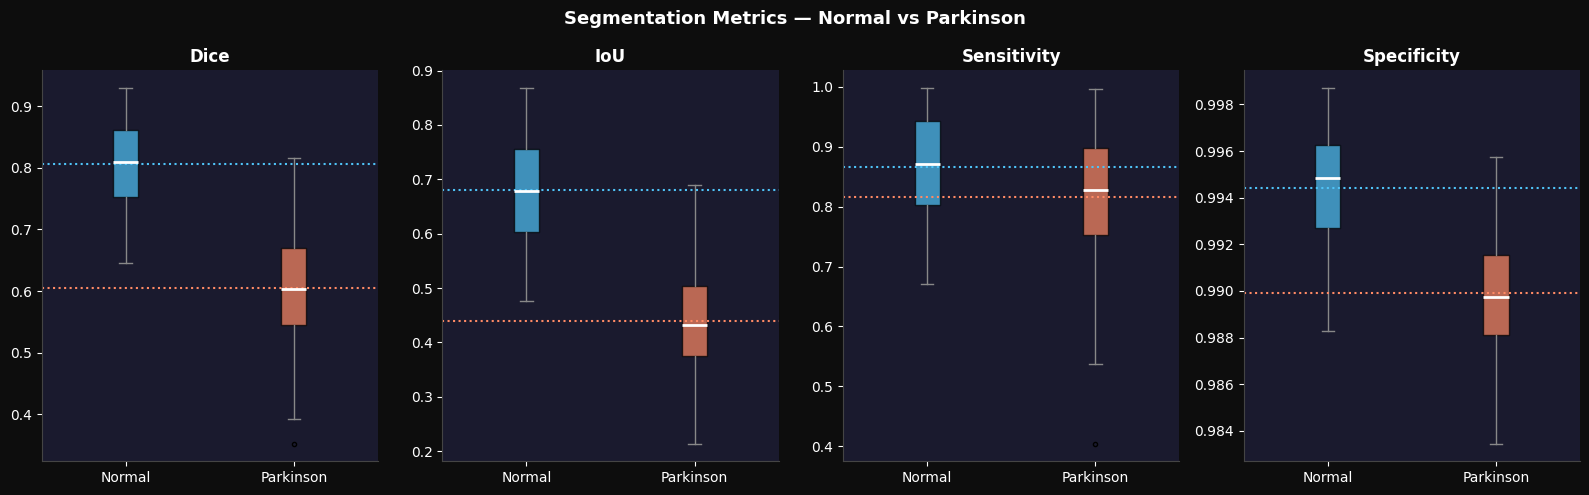


✅ Stage 7 complete.

📁 Saved figures:
   1. qualitative_segmentation_results.png    ← Main figure (a)(b)(c)(d)
   2. detailed_normal_segmentation.png        ← Detailed Normal panel
   3. detailed_parkinson_segmentation.png     ← Detailed Parkinson panel
   4. normal_vs_parkinson_sn_comparison.png  ← Side-by-side comparison
   5. stage7_metrics_boxplot.png              ← Quantitative metrics


In [ ]:
from sklearn.metrics import jaccard_score

# ── Per-sample metrics ────────────────────────────────────────────────────────
def per_sample_metrics(pred_m, gt_m):
    p = (pred_m>0.5).flatten().astype(int)
    g = (gt_m  >0.5).flatten().astype(int)
    inter = (p*g).sum()
    dice  = 2*inter/(p.sum()+g.sum()+1e-6)
    iou   = inter  /(p.sum()+g.sum()-inter+1e-6)
    sens  = inter  /(g.sum()+1e-6)
    spec  = ((1-p)*(1-g)).sum() / ((1-g).sum()+1e-6)
    return dice, iou, sens, spec

results = []
for i in range(len(X_test)):
    d, iou_s, sens, spec = per_sample_metrics(pred_masks[i], M_test[i])
    results.append({'Dice':d,'IoU':iou_s,'Sensitivity':sens,
                    'Specificity':spec,'Label':y_test[i]})
import pandas as pd
res_df = pd.DataFrame(results)

print('═'*60)
print('     QUANTITATIVE SEGMENTATION METRICS — PPMI DATASET')
print('═'*60)
for metric in ['Dice','IoU','Sensitivity','Specificity']:
    all_m  = res_df[metric]
    norm_m = res_df[res_df['Label']==0][metric]
    park_m = res_df[res_df['Label']==1][metric]
    print(f'\n  {metric}:')
    print(f'    Overall    : {all_m.mean():.4f} ± {all_m.std():.4f}')
    print(f'    Normal     : {norm_m.mean():.4f} ± {norm_m.std():.4f}')
    print(f'    Parkinson  : {park_m.mean():.4f} ± {park_m.std():.4f}')

print()
print(f'  Test samples  : {len(res_df)} (Normal:{(y_test==0).sum()}  Parkinson:{(y_test==1).sum()})')
print('═'*60)

# ── Metric comparison plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.patch.set_facecolor('#0D0D0D')
fig.suptitle('Segmentation Metrics — Normal vs Parkinson', fontsize=13,
             fontweight='bold', color='white')
metrics = ['Dice','IoU','Sensitivity','Specificity']
colors  = ['#4FC3F7','#FF8A65']

for ax, metric in zip(axes, metrics):
    ax.set_facecolor('#1A1A2E')
    norm_vals = res_df[res_df['Label']==0][metric].values
    park_vals = res_df[res_df['Label']==1][metric].values
    bp = ax.boxplot([norm_vals, park_vals], labels=['Normal','Parkinson'],
                    patch_artist=True, medianprops=dict(color='white',lw=2),
                    whiskerprops=dict(color='#888888'),
                    capprops=dict(color='#888888'),
                    flierprops=dict(marker='o',color='#888888',markersize=3))
    bp['boxes'][0].set_facecolor('#4FC3F7'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#FF8A65'); bp['boxes'][1].set_alpha(0.7)
    ax.set_title(metric, color='white', fontweight='bold')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#444444'); ax.spines['left'].set_color('#444444')
    ax.spines['top'].set_visible(False);     ax.spines['right'].set_visible(False)
    ax.set_facecolor('#1A1A2E')
    # Add mean lines
    ax.axhline(norm_vals.mean(), color='#4FC3F7', linewidth=1.5, linestyle=':')
    ax.axhline(park_vals.mean(), color='#FF8A65', linewidth=1.5, linestyle=':')
    ax.set_xticklabels(['Normal','Parkinson'], color='white')

plt.tight_layout()
plt.savefig('stage7_metrics_boxplot.png', dpi=150, bbox_inches='tight',
            facecolor='#0D0D0D')
plt.show()

print('\n✅ Stage 7 complete.')
print('\n📁 Saved figures:')
print('   1. qualitative_segmentation_results.png    ← Main figure (a)(b)(c)(d)')
print('   2. detailed_normal_segmentation.png        ← Detailed Normal panel')
print('   3. detailed_parkinson_segmentation.png     ← Detailed Parkinson panel')
print('   4. normal_vs_parkinson_sn_comparison.png  ← Side-by-side comparison')
print('   5. stage7_metrics_boxplot.png              ← Quantitative metrics')
